# 03 — Visualization and Insights

Covers **Section 8 of the report — Data Visualization and Insights**.

Twelve charts. Each answers one question and is followed by what it means for the inventory
decision — a chart without an interpretation is decoration.

Charts are saved to `images/` as they are drawn, ready to drop into the report.

**Input:** the tables built by `02_cleaning.ipynb`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
IMG  = ROOT / "images"; IMG.mkdir(exist_ok=True)

plt.rcParams.update({"figure.figsize": (10,5), "figure.dpi": 120, "savefig.dpi": 140,
                     "savefig.bbox": "tight", "font.size": 11,
                     "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

A, B, C = "#2A9D8F", "#E9C46A", "#C1121F"     # ABC classes
NAVY, WARM, GREY = "#264653", "#E76F51", "#8D99AE"

tx      = pd.read_csv(PROC/"transactions_clean.csv", parse_dates=["date","week"])
weekly  = pd.read_csv(PROC/"sku_weekly.csv", parse_dates=["week"])
returns = pd.read_csv(PROC/"returns.csv")
absence = pd.read_csv(PROC/"absence_candidates.csv", parse_dates=["gap_start","gap_end"])

print(f"transactions : {len(tx):,}")
print(f"SKU-weeks    : {len(weekly):,}")
print(f"returns      : {len(returns):,}")
print(f"absences     : {len(absence):,}")

transactions : 1,014,751
SKU-weeks    : 196,242
returns      : 19,165
absences     : 6,896


## Building the SKU profile

Everything downstream needs one row per SKU carrying revenue, volume and volatility. This is
also where **ABC** and **XYZ** are computed, because both charts and models use them.

In [2]:
n_weeks = weekly["week"].nunique()

sku = (weekly.groupby("StockCode")
       .agg(revenue=("revenue","sum"), units=("units","sum"),
            weeks_active=("week","nunique"), mean_wk=("units","mean"),
            sd_wk=("units","std"))
       .reset_index())
sku["sd_wk"] = sku["sd_wk"].fillna(0)

# XYZ uses the coefficient of variation across ALL weeks in the period, not only
# the weeks with sales — a SKU that sells nothing for 40 weeks is volatile, and
# ignoring the zero weeks would hide exactly the erratic demand XYZ exists to find.
tot = weekly.groupby("StockCode")["units"].sum()
mean_all = tot / n_weeks
ss = weekly.groupby("StockCode")["units"].apply(lambda s: (s**2).sum())
var_all = ss/n_weeks - mean_all**2
sku["cv"] = np.sqrt(var_all.clip(lower=0)).reindex(sku.StockCode).values / mean_all.reindex(sku.StockCode).values

sku = sku.sort_values("revenue", ascending=False).reset_index(drop=True)
sku["cum_share"] = sku["revenue"].cumsum() / sku["revenue"].sum()
sku["ABC"] = np.where(sku.cum_share <= .80, "A", np.where(sku.cum_share <= .95, "B", "C"))
sku["XYZ"] = np.where(sku.cv <= 0.75, "X", np.where(sku.cv <= 1.5, "Y", "Z"))
sku["class"] = sku.ABC + sku.XYZ

name = tx.drop_duplicates("StockCode").set_index("StockCode")["product"]
sku["product"] = sku.StockCode.map(name)

print(sku.groupby("ABC").agg(SKUs=("StockCode","size"), revenue=("revenue","sum")).assign(
    pct_skus=lambda d: (100*d.SKUs/d.SKUs.sum()).round(1),
    pct_rev=lambda d: (100*d.revenue/d.revenue.sum()).round(1)).to_string())
sku.to_csv(PROC/"sku_profile.csv", index=False)

     SKUs      revenue  pct_skus  pct_rev
ABC                                      
A    1030  15757601.98      21.8     80.0
B    1263   2956959.81      26.7     15.0
C    2431    985171.02      51.5      5.0


## Chart 1 — Revenue over time

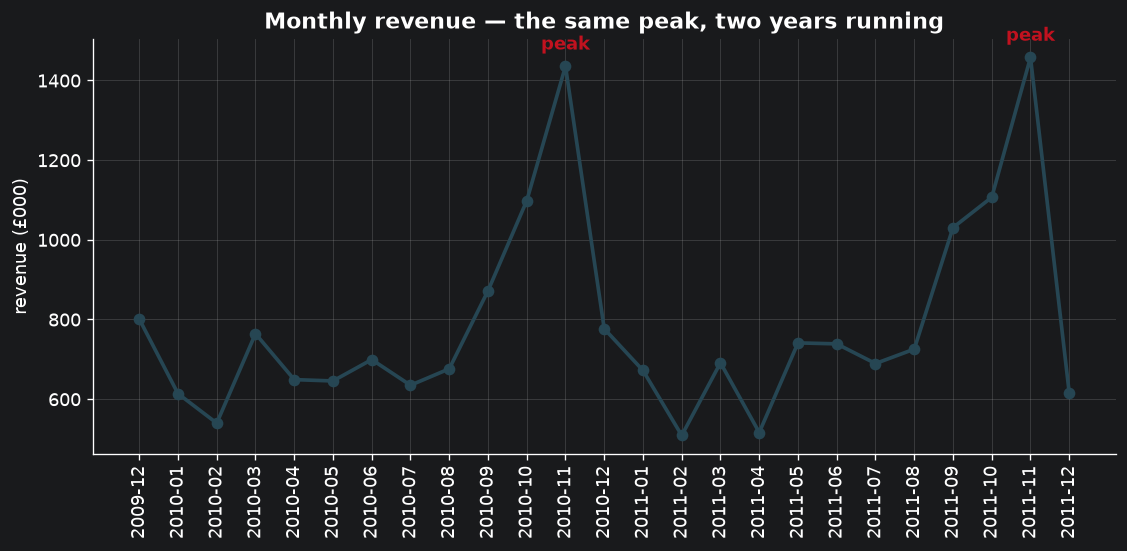

date
2009-12     801103.0
2010-01     613851.0
2010-02     539745.0
2010-03     764334.0
2010-04     648994.0
2010-05     645645.0
2010-06     699316.0
2010-07     634897.0
2010-08     676061.0
2010-09     871878.0
2010-10    1098018.0
2010-11    1435680.0
2010-12     776710.0
2011-01     671933.0
2011-02     508886.0
2011-03     691258.0
2011-04     516218.0
2011-05     741192.0
2011-06     738752.0
2011-07     689364.0
2011-08     725514.0
2011-09    1030475.0
2011-10    1106670.0
2011-11    1457746.0
2011-12     615493.0
Freq: M


In [3]:
m = tx.groupby(tx.date.dt.to_period("M"))["revenue"].sum()
fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(m.index.astype(str), m.values/1000, marker="o", lw=2.2, color=NAVY)
for lbl in ["2010-11","2011-11"]:
    if lbl in m.index.astype(str):
        i = list(m.index.astype(str)).index(lbl)
        ax.annotate("peak", (i, m.values[i]/1000), textcoords="offset points",
                    xytext=(0,10), ha="center", color=C, fontweight="bold")
ax.set_ylabel("revenue (£000)"); ax.tick_params(axis="x", rotation=90)
ax.set_title("Monthly revenue — the same peak, two years running")
fig.savefig(IMG/"chart_01_monthly_revenue.png"); plt.show()
print(m.round(0).to_string())

November is the peak in **both** years, roughly double the summer months. Because it repeats,
it is a **usable seasonal signal** rather than a one-off — which is what makes forecasting
worth doing at all.

**Inventory consequence:** stock cover set on an annual average will be far too thin in
October–November and far too heavy in February–April. The reorder points in objective 7 have to
be seasonal, not static.

*(December 2011 is partial — the data stops on the 9th. Do not read it as a collapse.)*

## Chart 2 — Revenue concentration: the case for ABC

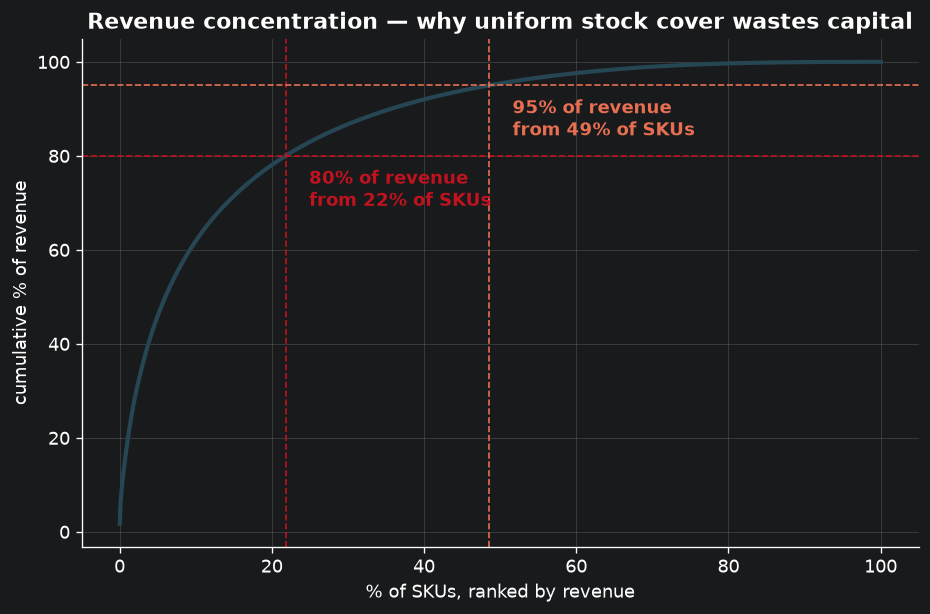

In [4]:
fig, ax = plt.subplots(figsize=(9,5.5))
x = np.arange(1, len(sku)+1)/len(sku)*100
ax.plot(x, sku.cum_share*100, lw=2.5, color=NAVY)
for share, col in [(80,C),(95,WARM)]:
    n = (sku.cum_share <= share/100).sum()+1
    ax.axhline(share, ls="--", color=col, lw=1); ax.axvline(100*n/len(sku), ls="--", color=col, lw=1)
    ax.annotate(f"{share}% of revenue\nfrom {100*n/len(sku):.0f}% of SKUs", (100*n/len(sku), share),
                textcoords="offset points", xytext=(14,-30), color=col, fontweight="bold")
ax.set_xlabel("% of SKUs, ranked by revenue"); ax.set_ylabel("cumulative % of revenue")
ax.set_title("Revenue concentration — why uniform stock cover wastes capital")
fig.savefig(IMG/"chart_02_pareto.png"); plt.show()

About **22% of SKUs generate 80% of revenue**; the bottom half of the catalogue contributes
roughly 5%.

**This is the problem statement's second blind spot in one chart.** Applying the same stock
cover across a catalogue this skewed guarantees both failures at once — capital tied up in the
long tail, and thin cover on the items that actually pay.

## Chart 3 — Basket sizes: the case for association mining

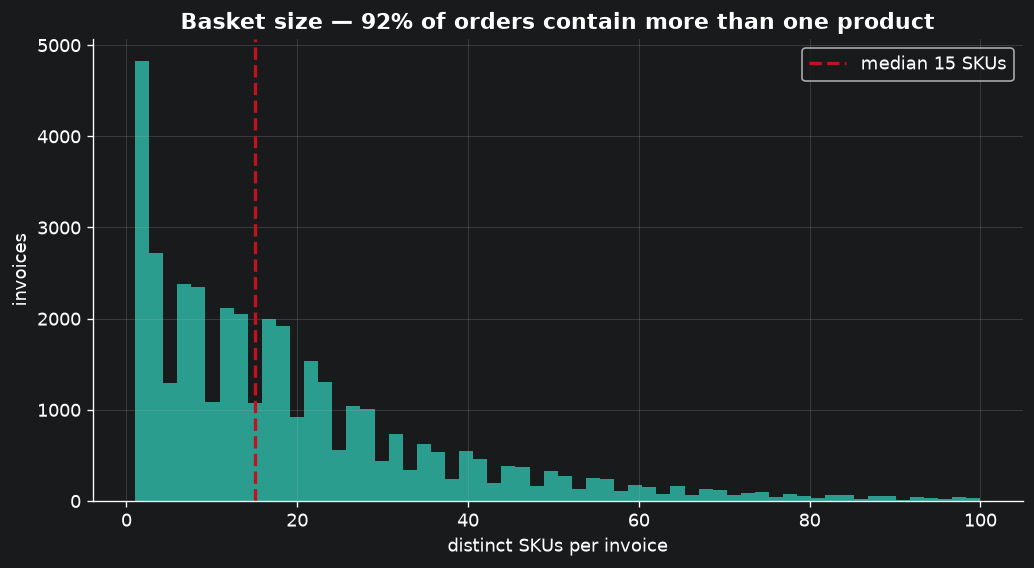

single-item 8.1%  |  median 15  |  95th 73  |  max 1,106


In [5]:
bs = tx.groupby("Invoice")["StockCode"].nunique()
fig, ax = plt.subplots()
ax.hist(bs[bs<=100], bins=60, color=A)
ax.axvline(bs.median(), color=C, ls="--", lw=2, label=f"median {bs.median():.0f} SKUs")
ax.set_xlabel("distinct SKUs per invoice"); ax.set_ylabel("invoices")
ax.set_title(f"Basket size — {100*(bs>1).mean():.0f}% of orders contain more than one product")
ax.legend(); fig.savefig(IMG/"chart_03_basket_size.png"); plt.show()
print(f"single-item {100*(bs==1).mean():.1f}%  |  median {bs.median():.0f}  |  95th {bs.quantile(.95):.0f}  |  max {bs.max():,}")

Around **92% of invoices contain two or more products**, median 17.

**This is the first blind spot made concrete.** Ordering each product independently ignores the
structure of nine out of ten orders. If almost every order is an assortment, then a stockout
does not cost one line — it puts an entire basket at risk.

## Chart 4 — Where the revenue actually is

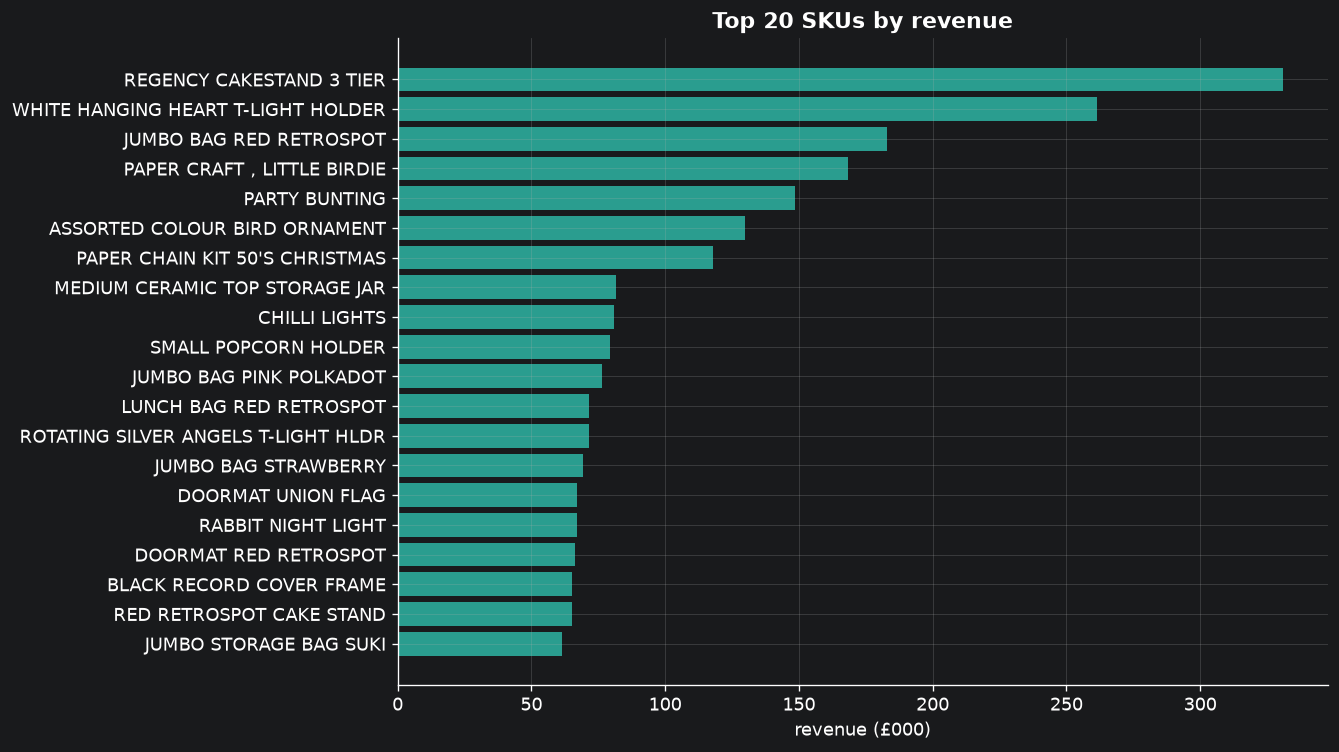

top 20 SKUs = 11.5% of total revenue


In [6]:
top = sku.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(top["product"].str[:38], top.revenue/1000, color=[A if k=="A" else B for k in top.ABC])
ax.set_xlabel("revenue (£000)")
ax.set_title("Top 20 SKUs by revenue")
fig.savefig(IMG/"chart_04_top_skus.png"); plt.show()
print(f"top 20 SKUs = {100*sku.head(20).revenue.sum()/sku.revenue.sum():.1f}% of total revenue")

The twenty largest SKUs alone carry a meaningful share of total revenue. These are the items
where a stockout is most expensive and where forecast accuracy matters most — and they are few
enough to manage individually rather than by rule.

## Chart 5 — Volume against volatility: the XYZ axis

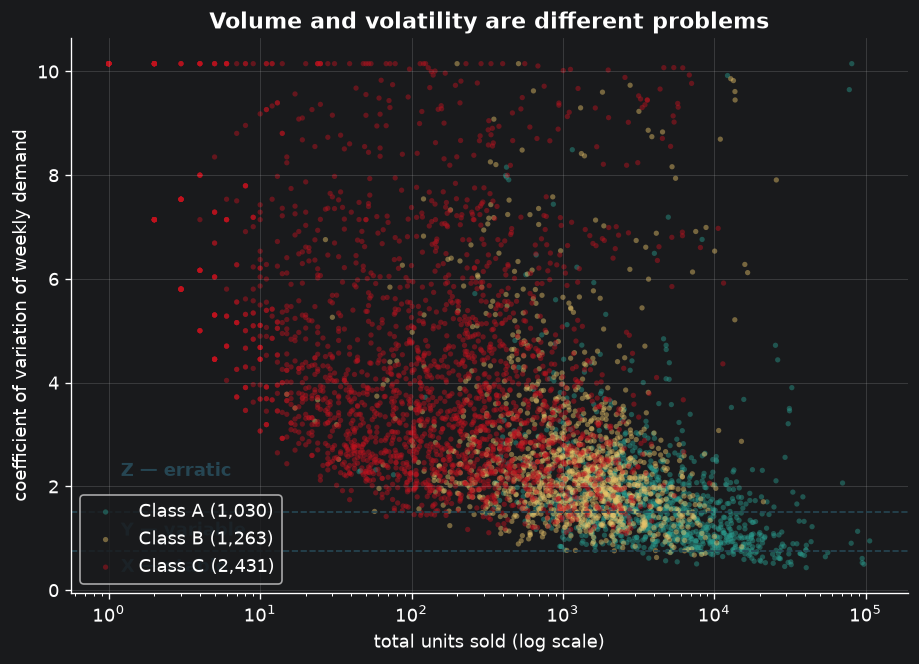

In [7]:
s = sku[(sku.units>0) & np.isfinite(sku.cv)]
fig, ax = plt.subplots(figsize=(9,6))
for k,col in [("A",A),("B",B),("C",C)]:
    g = s[s.ABC==k]
    ax.scatter(g.units, g.cv, s=10, alpha=.45, color=col, label=f"Class {k} ({len(g):,})", edgecolor="none")
ax.set_xscale("log")
ax.axhline(0.75, ls="--", color=NAVY, lw=1); ax.axhline(1.5, ls="--", color=NAVY, lw=1)
ax.text(s.units.min()*1.2, 0.35, "X — stable", color=NAVY, fontweight="bold")
ax.text(s.units.min()*1.2, 1.05, "Y — variable", color=NAVY, fontweight="bold")
ax.text(s.units.min()*1.2, 2.2, "Z — erratic", color=NAVY, fontweight="bold")
ax.set_xlabel("total units sold (log scale)"); ax.set_ylabel("coefficient of variation of weekly demand")
ax.set_title("Volume and volatility are different problems")
ax.legend(); fig.savefig(IMG/"chart_05_volume_volatility.png"); plt.show()

**The two axes are close to independent** — high-revenue items are not automatically stable, and
low-revenue items are not automatically erratic.

That independence is the whole argument for a **two-dimensional** classification. ABC alone
would tell you to protect the top sellers; it would not tell you that some of them are so
volatile that protecting them requires far more safety stock than their revenue justifies.

## Chart 6 — The nine-cell policy grid

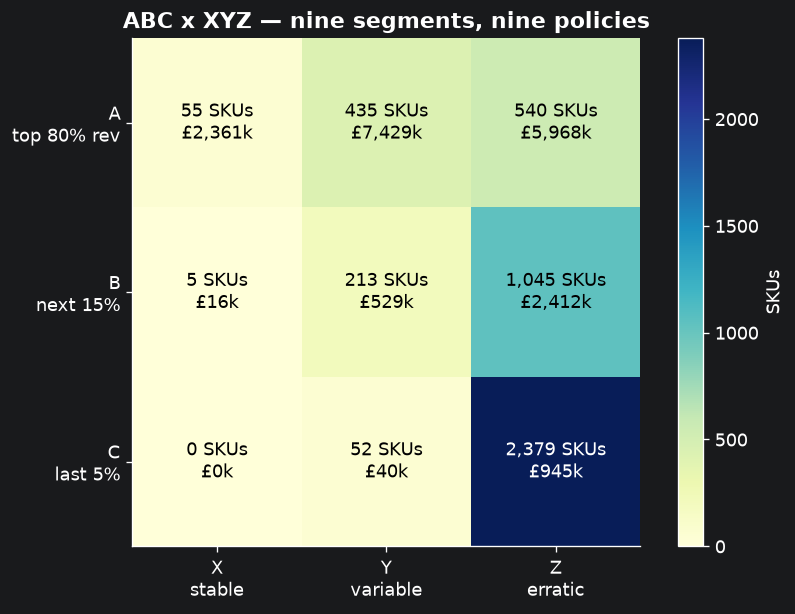

XYZ   X    Y     Z
ABC               
A    55  435   540
B     5  213  1045
C     0   52  2379


In [8]:
grid = sku.pivot_table(index="ABC", columns="XYZ", values="StockCode", aggfunc="count").fillna(0)
grid = grid.reindex(index=["A","B","C"], columns=["X","Y","Z"]).fillna(0)
rev  = sku.pivot_table(index="ABC", columns="XYZ", values="revenue", aggfunc="sum").reindex(
        index=["A","B","C"], columns=["X","Y","Z"]).fillna(0)

fig, ax = plt.subplots(figsize=(8,5.5))
im = ax.imshow(grid.values, cmap="YlGnBu")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{grid.values[i,j]:,.0f} SKUs\n£{rev.values[i,j]/1000:,.0f}k",
                ha="center", va="center", fontsize=11,
                color="white" if grid.values[i,j] > grid.values.max()*.5 else "black")
ax.set_xticks(range(3), ["X\nstable","Y\nvariable","Z\nerratic"])
ax.set_yticks(range(3), ["A\ntop 80% rev","B\nnext 15%","C\nlast 5%"])
ax.set_title("ABC x XYZ — nine segments, nine policies"); ax.grid(False)
plt.colorbar(im, ax=ax, label="SKUs")
fig.savefig(IMG/"chart_06_abc_xyz_grid.png"); plt.show()
print(grid.astype(int).to_string())

**This grid is the project's central deliverable.** Each cell needs a different policy:

| Cell | Meaning | Policy |
|---|---|---|
| **AX** | high revenue, predictable | tight reorder point, minimal safety stock — forecasting works here |
| **AZ** | high revenue, erratic | expensive to protect; needs high safety stock or supplier agility |
| **CX** | low revenue, predictable | automate entirely, review rarely |
| **CZ** | low revenue, erratic | **candidates for delisting or make-to-order** — the worst capital-to-value ratio in the catalogue |

Uniform stock cover treats all nine identically. That is the failure this chart makes visible.

## Chart 7 — Why one policy cannot fit all

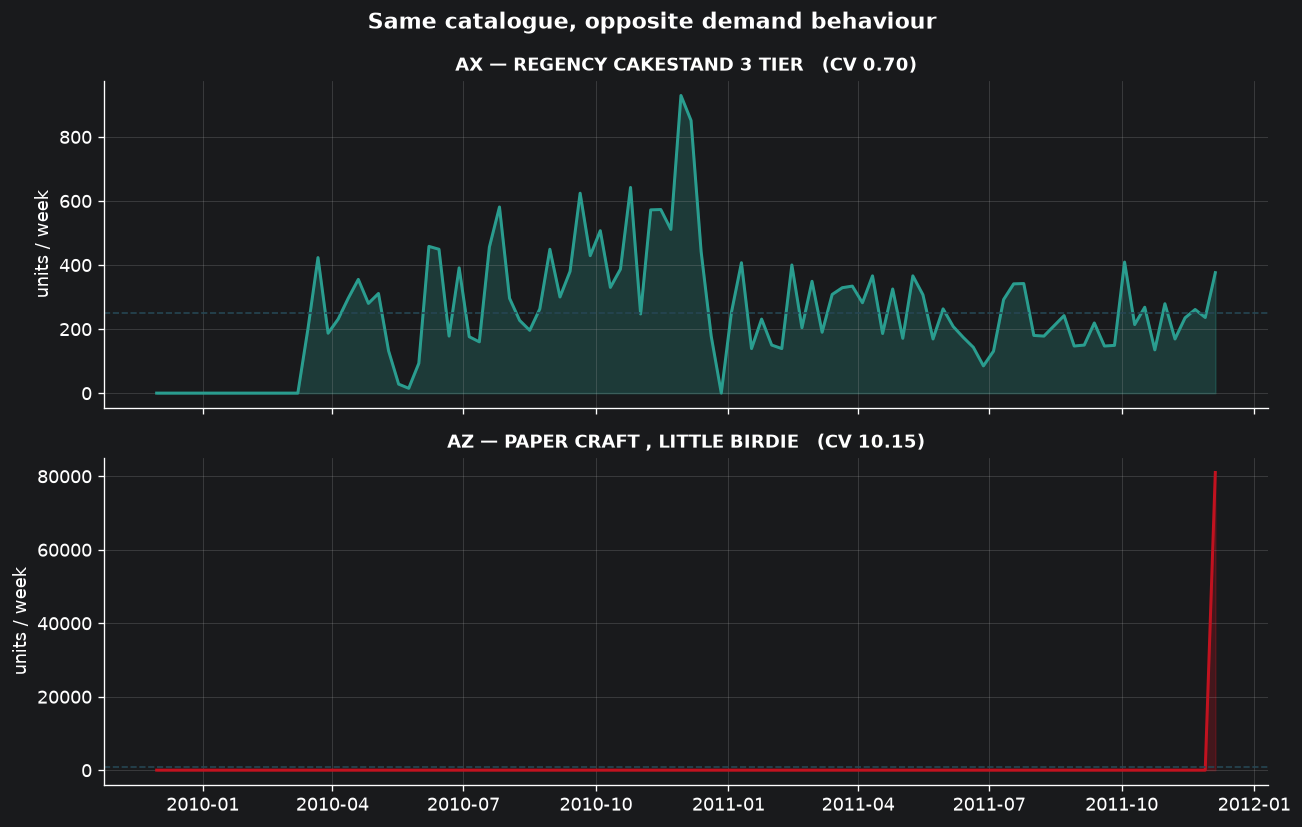

In [9]:
def pick(cls):
    g = sku[sku["class"]==cls].sort_values("revenue", ascending=False)
    return g.iloc[0] if len(g) else None

fig, axes = plt.subplots(2, 1, figsize=(11,7), sharex=True)
for ax, cls, col in zip(axes, ["AX","AZ"], [A, C]):
    r = pick(cls)
    if r is None:
        continue
    w = weekly[weekly.StockCode==r.StockCode].set_index("week")["units"]
    full = w.reindex(pd.date_range(weekly.week.min(), weekly.week.max(), freq="W-MON"), fill_value=0)
    ax.plot(full.index, full.values, lw=1.8, color=col)
    ax.fill_between(full.index, full.values, alpha=.25, color=col)
    ax.axhline(full.mean(), ls="--", color=NAVY, lw=1)
    ax.set_title(f"{cls} — {str(r['product'])[:44]}   (CV {r.cv:.2f})", fontsize=11)
    ax.set_ylabel("units / week")
fig.suptitle("Same catalogue, opposite demand behaviour", fontweight="bold", fontsize=13)
fig.tight_layout(); fig.savefig(IMG/"chart_07_demand_profiles.png"); plt.show()

Two products, both in revenue class A, both important. One sells a steady quantity every week;
the other arrives in unpredictable bursts.

**A single reorder rule applied to both is wrong twice** — too much stock on the steady one,
too little when the erratic one spikes. This chart is the clearest single answer to *"why not
just use a moving average for everything?"*

## Chart 8 — Weekly rhythm

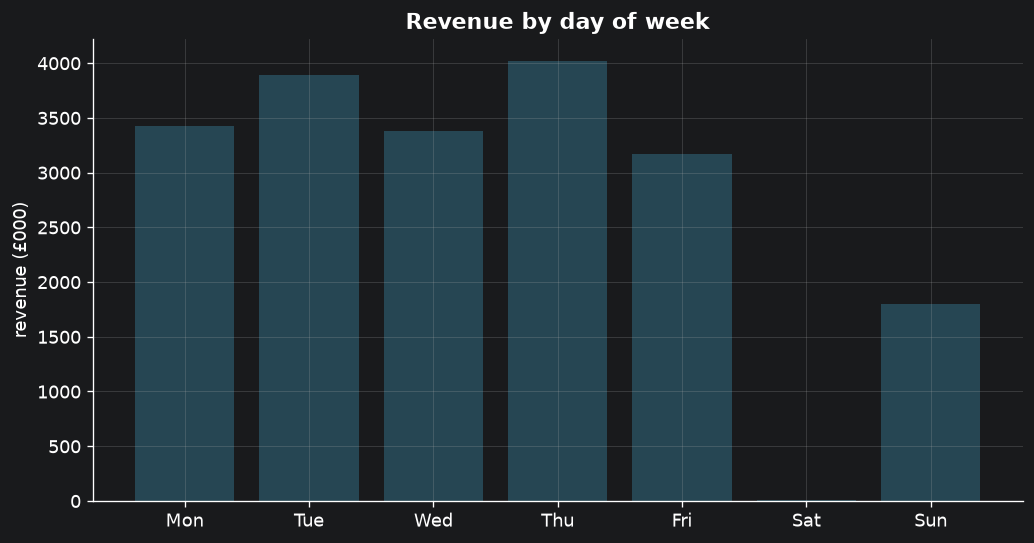

date
0    3424338.0
1    3888214.0
2    3383967.0
3    4019897.0
4    3172662.0
5       9803.0
6    1800852.0


In [10]:
dow = tx.groupby(tx.date.dt.dayofweek)["revenue"].sum()
names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, ax = plt.subplots()
ax.bar([names[i] for i in dow.index], dow.values/1000, color=NAVY)
ax.set_ylabel("revenue (£000)"); ax.set_title("Revenue by day of week")
fig.savefig(IMG/"chart_08_day_of_week.png"); plt.show()
print(dow.round(0).to_string())

Ordering is concentrated in the working week and effectively stops at the weekend — consistent
with a **wholesale** customer base placing orders during business hours, not consumers shopping
on Saturdays.

**Operational consequence:** replenishment lead times should be counted in working days, not
calendar days. A three-day lead time placed on a Thursday is not three days.

## Chart 9 — Returns

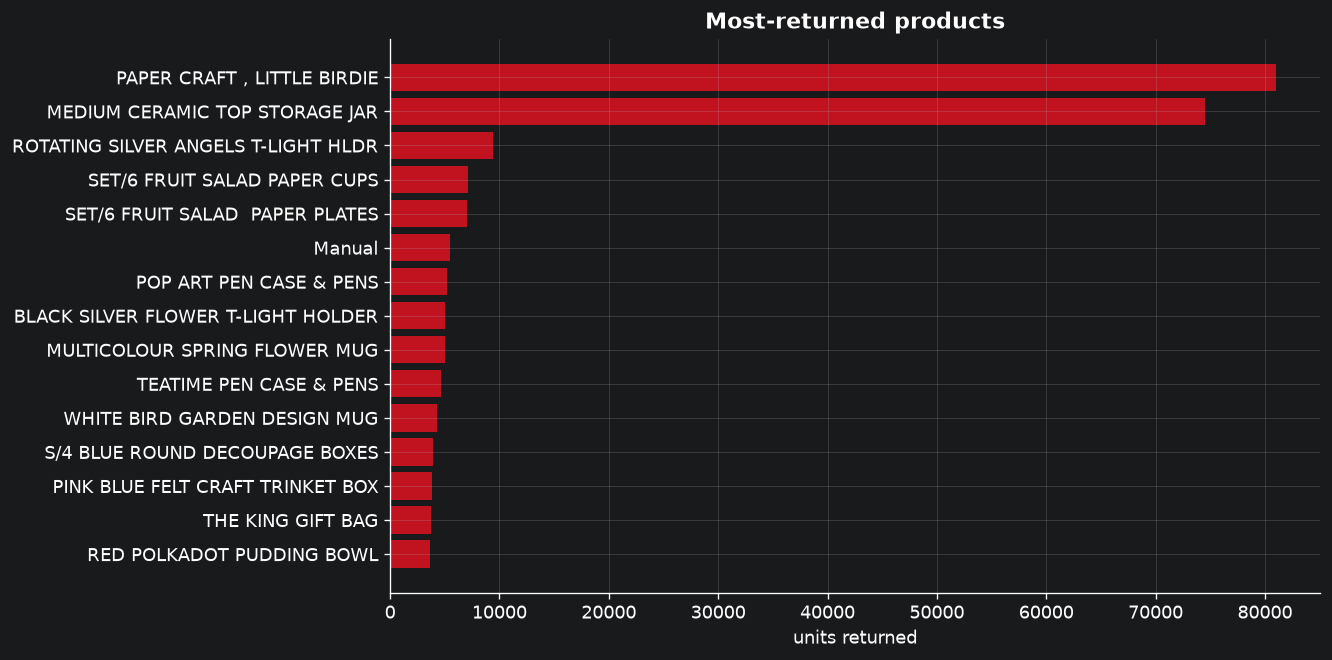

total return lines 19,165 | value £1,465,304


In [11]:
returns["value"] = returns.Quantity * returns.Price
rr = (returns.groupby("Description")
      .agg(units=("Quantity","sum"), value=("value","sum"))
      .sort_values("units").head(15).iloc[::-1])
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(rr.index.str[:38], -rr.units, color=C)
ax.set_xlabel("units returned"); ax.set_title("Most-returned products")
fig.savefig(IMG/"chart_09_returns.png"); plt.show()
print(f"total return lines {len(returns):,} | value £{-returns.value.sum():,.0f}")

Returns are concentrated in a small number of products.

**Why this matters for stock:** a high-return SKU has *lower true demand* than its gross sales
suggest. Setting a reorder point on gross units systematically over-orders exactly these items.
Secondary objective 11 uses this as a demand-quality adjustment.

## Chart 10 — How much of the catalogue is actually active

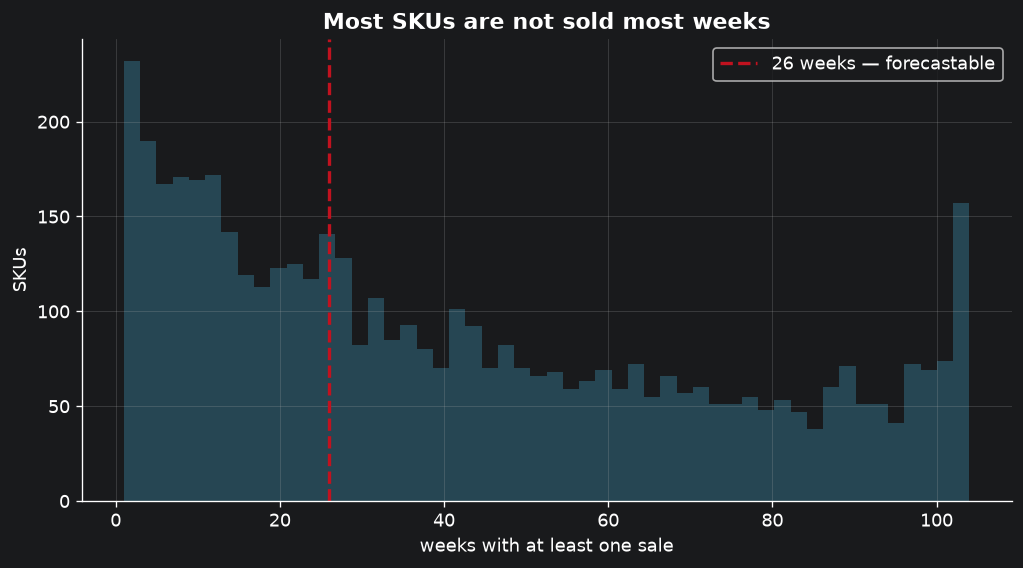

median weeks active : 34 of 104
SKUs active 26+ wks : 2,810
SKUs active <8 wks  : 664


In [12]:
fig, ax = plt.subplots()
ax.hist(sku.weeks_active, bins=52, color=NAVY)
ax.axvline(26, color=C, ls="--", lw=2, label="26 weeks — forecastable")
ax.set_xlabel("weeks with at least one sale"); ax.set_ylabel("SKUs")
ax.set_title("Most SKUs are not sold most weeks")
ax.legend(); fig.savefig(IMG/"chart_10_sku_activity.png"); plt.show()
print(f"median weeks active : {sku.weeks_active.median():.0f} of {n_weeks}")
print(f"SKUs active 26+ wks : {(sku.weeks_active>=26).sum():,}")
print(f"SKUs active <8 wks  : {(sku.weeks_active<8).sum():,}")

The median SKU sells in only about a third of the weeks in the period. Demand at SKU level is
**intermittent**, not continuous.

**This is the honest constraint on objective 6.** Classical forecasting needs a reasonably
regular series. It will work for the ~2,800 SKUs with substantial history and will fail for the
long tail — and the right response to that failure is a different *policy*, not a bigger model.

## Chart 11 — Absence episodes: the pull-through test

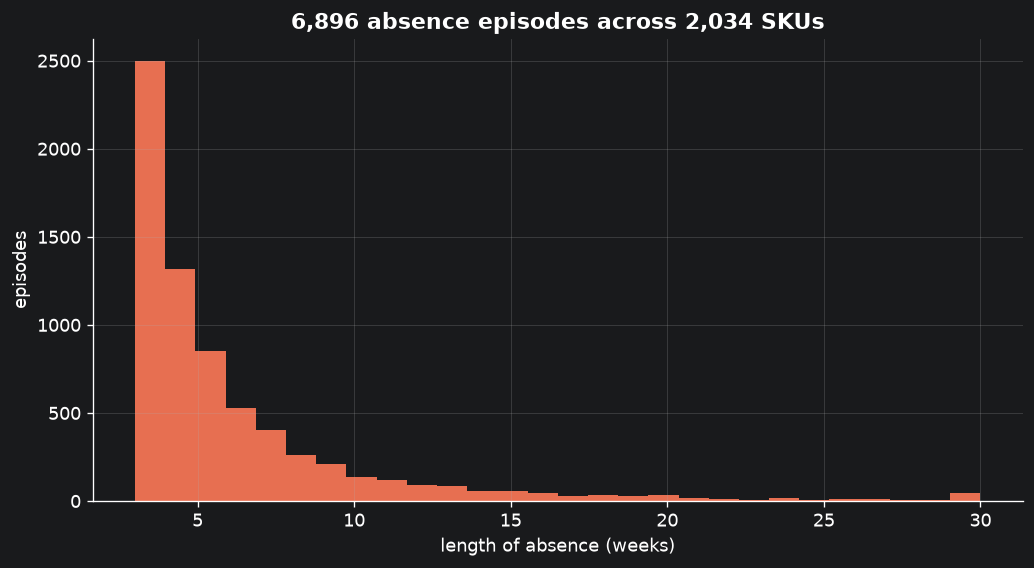

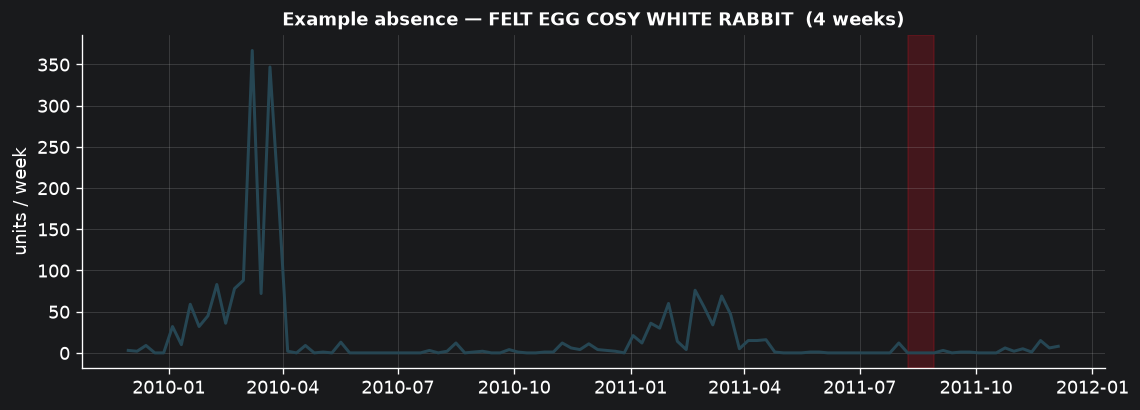

In [13]:
if len(absence) == 0:
    print("No absence episodes in this dataset — objective 4 cannot be tested.")
    print("Check the thresholds in notebook 02 (MIN_BEFORE / MIN_GAP / MIN_AFTER).")
else:
    fig, ax = plt.subplots()
    ax.hist(absence.gap_weeks.clip(upper=30), bins=28, color=WARM)
    ax.set_xlabel("length of absence (weeks)"); ax.set_ylabel("episodes")
    ax.set_title(f"{len(absence):,} absence episodes across {absence.StockCode.nunique():,} SKUs")
    fig.savefig(IMG/"chart_11_absences.png"); plt.show()

    ex = absence.sort_values("gap_weeks", ascending=False).iloc[len(absence)//2]
    w = weekly[weekly.StockCode == ex.StockCode].set_index("week")["units"]
    full = w.reindex(pd.date_range(weekly.week.min(), weekly.week.max(), freq="W-MON"), fill_value=0)
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(full.index, full.values, lw=1.8, color=NAVY)
    ax.axvspan(ex.gap_start, ex.gap_end, color=C, alpha=.25)
    ax.set_title(f"Example absence — {str(name.get(ex.StockCode,''))[:40]}  ({ex.gap_weeks} weeks)", fontsize=11)
    ax.set_ylabel("units / week")
    fig.savefig(IMG/"chart_11b_absence_example.png"); plt.show()

A SKU sells steadily, disappears for several weeks, then returns. Requiring the **return** is
what separates a stockout-like gap from a discontinued line.

**This is the raw material for objective 4.** Notebook 04 takes each shaded window and asks
whether the sales of that item's strongest association partners fell during it — turning
pull-through from an assumption into a measured result.

## Chart 12 — Where the capital sits versus where the revenue comes from

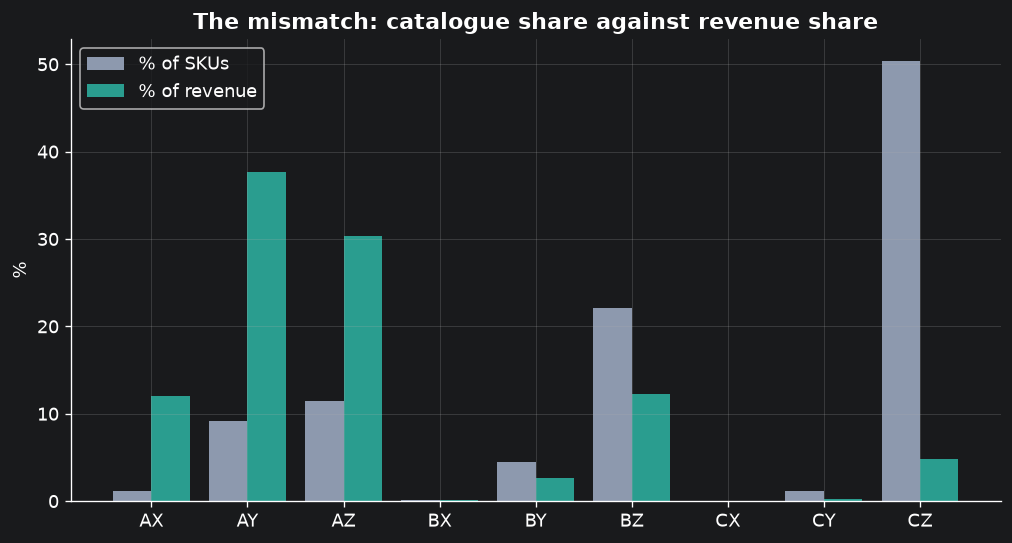

         SKUs    revenue  pct_skus  pct_rev
class                                      
AX       55.0  2360816.2       1.2     12.0
AY      435.0  7429230.2       9.2     37.7
AZ      540.0  5967555.6      11.4     30.3
BX        5.0    16474.0       0.1      0.1
BY      213.0   528627.4       4.5      2.7
BZ     1045.0  2411858.5      22.1     12.2
CX        0.0        0.0       0.0      0.0
CY       52.0    39951.9       1.1      0.2
CZ     2379.0   945219.1      50.4      4.8


In [14]:
g = sku.groupby("class").agg(SKUs=("StockCode","size"), revenue=("revenue","sum")).reindex(
    ["AX","AY","AZ","BX","BY","BZ","CX","CY","CZ"]).fillna(0)
g["pct_skus"] = 100*g.SKUs/g.SKUs.sum()
g["pct_rev"]  = 100*g.revenue/g.revenue.sum()

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(g))
ax.bar(x-0.2, g.pct_skus, 0.4, label="% of SKUs", color=GREY)
ax.bar(x+0.2, g.pct_rev, 0.4, label="% of revenue", color=A)
ax.set_xticks(x, g.index); ax.set_ylabel("%")
ax.set_title("The mismatch: catalogue share against revenue share")
ax.legend(); fig.savefig(IMG/"chart_12_mismatch.png"); plt.show()
print(g.round(1).to_string())

**The closing argument of section 8.** The CZ cell — low revenue, erratic demand — occupies a
large share of the catalogue while contributing very little revenue. AX occupies few SKUs and
contributes a great deal.

Every SKU in that catalogue carries stock, warehouse space and working capital. Uniform cover
spends the same protection on both ends of this chart. **Where the SKUs are is not where the
money is**, and that gap is what the inventory policy in notebook 04 is designed to close.

## Summary — the five findings for the report

1. **Demand is strongly seasonal and repeats** — November peaks in both years, so static stock
   cover is wrong for a third of the year.
2. **Revenue is extremely concentrated** — 22% of SKUs, 80% of revenue.
3. **92% of orders are multi-item** — products cannot sensibly be ordered as if independent.
4. **Volume and volatility are near-independent** — which is why ABC alone is insufficient and
   the nine-cell grid is needed.
5. **Demand is intermittent for most SKUs** — the median sells in a third of weeks, so
   forecasting is viable for the top ~2,800 and must be replaced by policy for the rest.

Finding 4 is the one to lead with. It is the least obvious, and it is the direct justification
for the classification that the whole inventory recommendation rests on.

Next: `04_modeling.ipynb` — association rules, the pull-through test, forecasting, and the
simulated inventory policy.